# Анализ интернет-магазина "В один клик"

Цель: персонализировать предложения постоянным клиентам, чтобы увеличить их покупательскую активность.

План работы:
1) Обзор данных
2) Предобработка данных
3) Исследовательский анализ данных
4) Корреляционный анализ признаков
5) Использование пайплайнов
6) Анализ важности признаков
7) Сегментация покупателей
8) Общий вывод

# Обзор данных

In [1]:
!pip install shap
!pip install ipywidgets
!pip install jupyterlab_widgets


[notice] A new release of pip is available: 23.2.1 -> 25.1.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 23.2.1 -> 25.1.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 23.2.1 -> 25.1.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import shap

from sklearn.cluster import KMeans
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    make_scorer,
    roc_auc_score,
    classification_report,
    roc_curve
)
from sklearn.model_selection import (
    GridSearchCV,
    StratifiedKFold,
    train_test_split
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    MinMaxScaler,
    OneHotEncoder,
    OrdinalEncoder,
    StandardScaler
)
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

import patsy as pt
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [3]:
try:
    market_file = pd.read_csv('market_file.csv')
except:
    market_file = pd.read_csv('https://code.s3.yandex.net/datasets/market_file.csv')

market_file.head()

,id,Покупательская активность,Тип сервиса,Разрешить сообщать,Маркет_актив_6_мес,Маркет_актив_тек_мес,Длительность,Акционные_покупки,Популярная_категория,Средний_просмотр_категорий_за_визит,Неоплаченные_продукты_штук_квартал,Ошибка_сервиса,Страниц_за_визит
0,215348,Снизилась,премиум,да,3.4,5,121,0.00,Товары для детей,6,2,1,5
1,215349,Снизилась,премиум,да,4.4,4,819,0.75,Товары для детей,4,4,2,5
2,215350,Снизилась,стандартт,нет,4.9,3,539,0.14,Домашний текстиль,5,2,1,5
3,215351,Снизилась,стандартт,да,3.2,5,896,0.99,Товары для детей,5,0,6,4
4,215352,Снизилась,стандартт,нет,5.1,3,1064,0.94,Товары для детей,3,2,3,2


In [4]:
market_file.columns = (
    market_file.columns
    .str.lower()
    .str.replace(r'\s+', '_', regex=True)
)
market_file.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1300 entries, 0 to 1299
Data columns (total 13 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   id                                   1300 non-null   int64  
 1   покупательская_активность            1300 non-null   object 
 2   тип_сервиса                          1300 non-null   object 
 3   разрешить_сообщать                   1300 non-null   object 
 4   маркет_актив_6_мес                   1300 non-null   float64
 5   маркет_актив_тек_мес                 1300 non-null   int64  
 6   длительность                         1300 non-null   int64  
 7   акционные_покупки                    1300 non-null   float64
 8   популярная_категория                 1300 non-null   object 
 9   средний_просмотр_категорий_за_визит  1300 non-null   int64  
 10  неоплаченные_продукты_штук_квартал   1300 non-null   int64  
 11  ошибка_сервиса                

In [5]:
try:
    market_money = pd.read_csv('market_money.csv')
except:
    market_money = pd.read_csv('https://code.s3.yandex.net/datasets/market_money.csv')

market_money.head()

,id,Период,Выручка
0,215348,препредыдущий_месяц,0.0
1,215348,текущий_месяц,3293.1
2,215348,предыдущий_месяц,0.0
3,215349,препредыдущий_месяц,4472.0
4,215349,текущий_месяц,4971.6


In [6]:
market_money.columns = (
    market_money.columns
    .str.lower()
    .str.replace(r'\s+', '_', regex=True)
)
market_money.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   id       3900 non-null   int64  
 1   период   3900 non-null   object 
 2   выручка  3900 non-null   float64
dtypes: float64(1), int64(1), object(1)
memory usage: 91.5+ KB


In [7]:
try:
    market_time = pd.read_csv('market_time.csv')
except:
    market_time = pd.read_csv('https://code.s3.yandex.net/datasets/market_time')

market_time.head()

,id,Период,минут
0,215348,текущий_месяц,14
1,215348,предыдцщий_месяц,13
2,215349,текущий_месяц,10
3,215349,предыдцщий_месяц,12
4,215350,текущий_месяц,13


In [8]:
market_time.columns = (
    market_time.columns
    .str.lower()
    .str.replace(r'\s+', '_', regex=True)
)
market_time.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2600 entries, 0 to 2599
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      2600 non-null   int64 
 1   период  2600 non-null   object
 2   минут   2600 non-null   int64 
dtypes: int64(2), object(1)
memory usage: 61.1+ KB


In [9]:
try:
    money = pd.read_csv('money.csv', sep=';', decimal=',')
except:
    money = pd.read_csv('https://code.s3.yandex.net/datasets/money.csv', sep=';', decimal=',')

money.head()

,id,Прибыль
0,215348,0.98
1,215349,4.16
2,215350,3.13
3,215351,4.87
4,215352,4.21


In [10]:
money.columns = (
    money.columns
    .str.lower()
    .str.replace(r'\s+', '_', regex=True)
)
money.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1300 entries, 0 to 1299
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   id       1300 non-null   int64  
 1   прибыль  1300 non-null   float64
dtypes: float64(1), int64(1)
memory usage: 20.4 KB


# Предобработка данных

<div style="border:solid blue 2px; padding: 20px">

<div class="alert alert-info">

Вообще не понял о чем речь

In [11]:
market_file.isna().sum().sum()

np.int64(0)

In [12]:
market_money.isna().sum().sum()

np.int64(0)

In [13]:
market_time.isna().sum().sum()

np.int64(0)

In [14]:
money.isna().sum().sum()

np.int64(0)

In [15]:
market_file.duplicated().sum()

np.int64(0)

In [16]:
market_money.duplicated().sum()

np.int64(0)

In [17]:
market_time.duplicated().sum()

np.int64(0)

In [18]:
money.duplicated().sum()

np.int64(0)

In [19]:
for _ in market_file.select_dtypes(include='object').columns:
    print(_, market_file[_].unique())

покупательская_активность ['Снизилась' 'Прежний уровень']
тип_сервиса ['премиум' 'стандартт' 'стандарт']
разрешить_сообщать ['да' 'нет']
популярная_категория ['Товары для детей' 'Домашний текстиль' 'Косметика и аксесуары'
 'Техника для красоты и здоровья' 'Кухонная посуда'
 'Мелкая бытовая техника и электроника']


In [20]:
market_file['тип_сервиса'] = market_file['тип_сервиса'].replace('стандартт', 'стандарт')
market_file['тип_сервиса'].unique()

array(['премиум', 'стандарт'], dtype=object)

In [21]:
market_file['популярная_категория'] = market_file['популярная_категория'].replace('Косметика и аксесуары', 'Косметика и аксессуары')
market_file['популярная_категория'].unique()

array(['Товары для детей', 'Домашний текстиль', 'Косметика и аксессуары',
       'Техника для красоты и здоровья', 'Кухонная посуда',
       'Мелкая бытовая техника и электроника'], dtype=object)

In [22]:
for _ in market_money.select_dtypes(include='object').columns:
    print(_, market_money[_].unique())

период ['препредыдущий_месяц' 'текущий_месяц' 'предыдущий_месяц']


In [23]:
for _ in market_time.select_dtypes(include='object').columns:
    print(_, market_time[_].unique())

период ['текущий_месяц' 'предыдцщий_месяц']


In [24]:
market_time['период'] = market_time['период'].replace('предыдцщий_месяц', 'предыдущий_месяц')
market_time['период'].unique()

array(['текущий_месяц', 'предыдущий_месяц'], dtype=object)

In [25]:
for _ in money.select_dtypes(include='object').columns:
    print(_, money[_].unique())

<div class="alert alert-info">
    <b>Вывод:</b>
    пропуски и явные дубликаты отсутствуют, неявные дубликаты устранены
</div>

# Исследовательский анализ данных

In [26]:
market_file.head()

,id,покупательская_активность,тип_сервиса,разрешить_сообщать,маркет_актив_6_мес,маркет_актив_тек_мес,длительность,акционные_покупки,популярная_категория,средний_просмотр_категорий_за_визит,неоплаченные_продукты_штук_квартал,ошибка_сервиса,страниц_за_визит
0,215348,Снизилась,премиум,да,3.4,5,121,0.00,Товары для детей,6,2,1,5
1,215349,Снизилась,премиум,да,4.4,4,819,0.75,Товары для детей,4,4,2,5
2,215350,Снизилась,стандарт,нет,4.9,3,539,0.14,Домашний текстиль,5,2,1,5
3,215351,Снизилась,стандарт,да,3.2,5,896,0.99,Товары для детей,5,0,6,4
4,215352,Снизилась,стандарт,нет,5.1,3,1064,0.94,Товары для детей,3,2,3,2


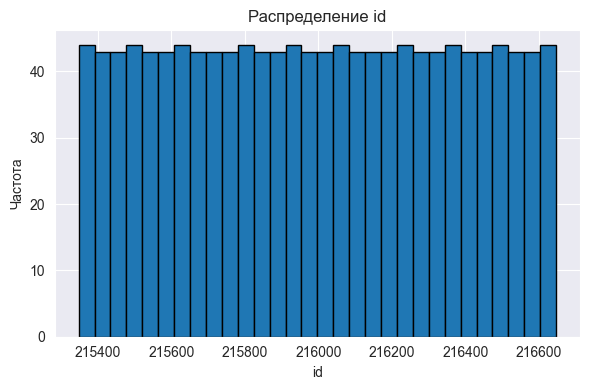

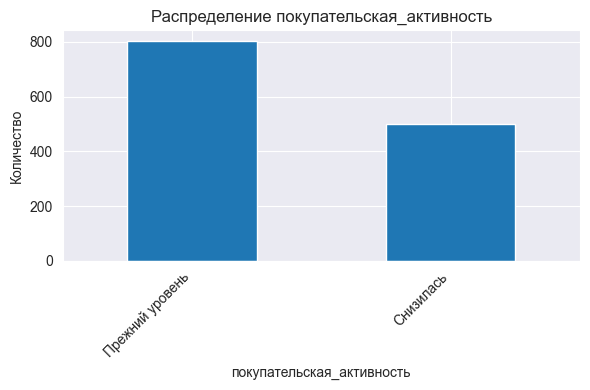

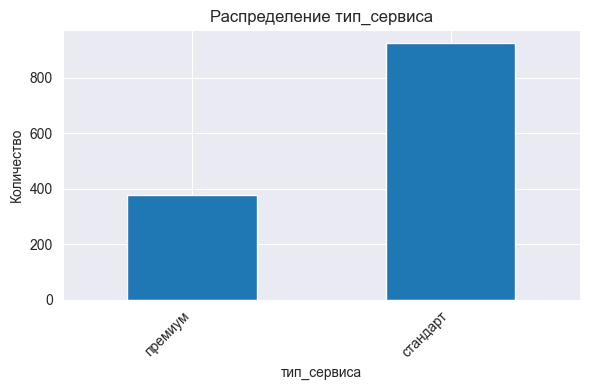

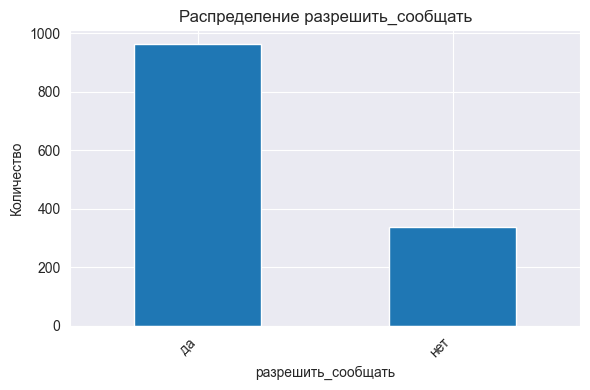

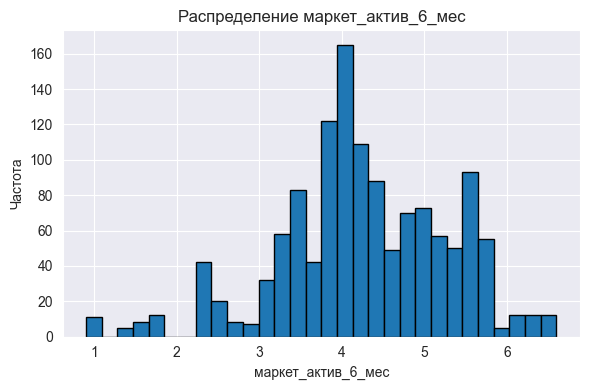

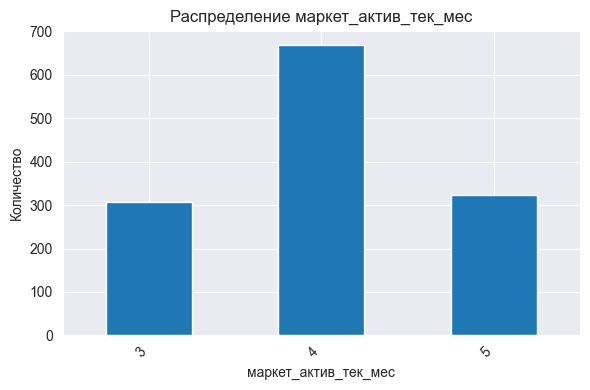

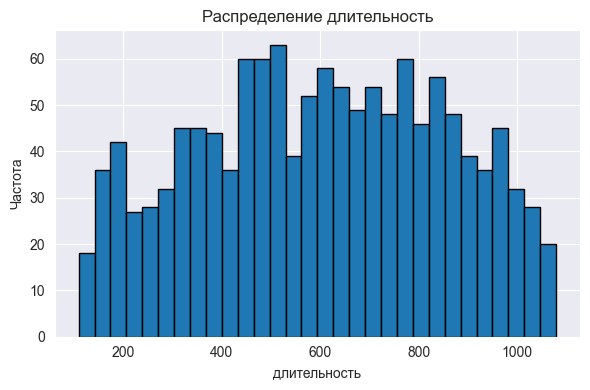

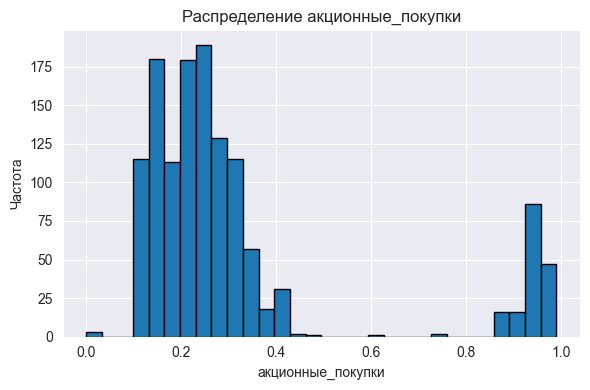

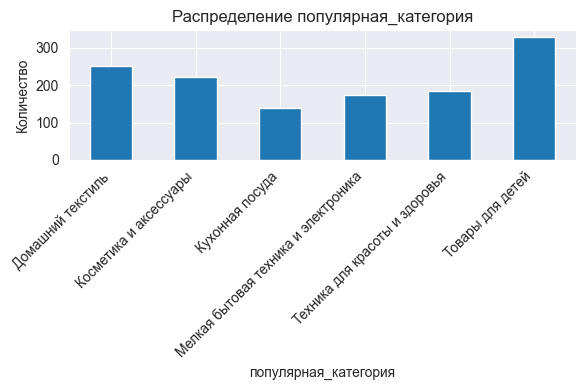

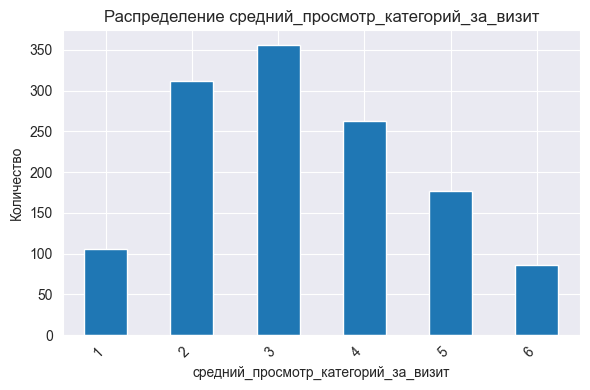

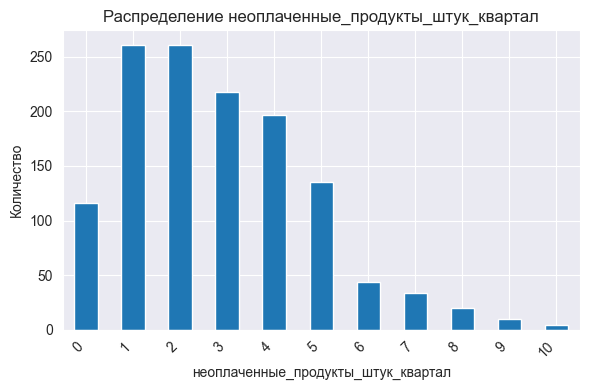

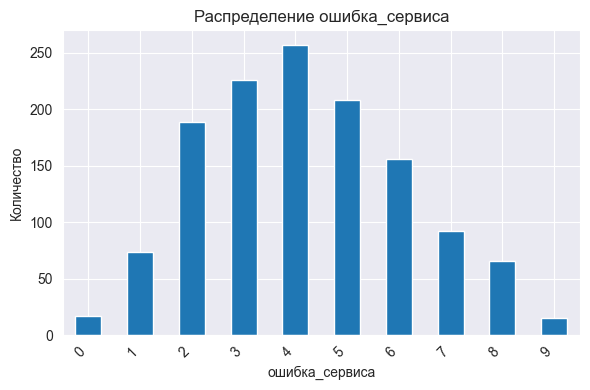

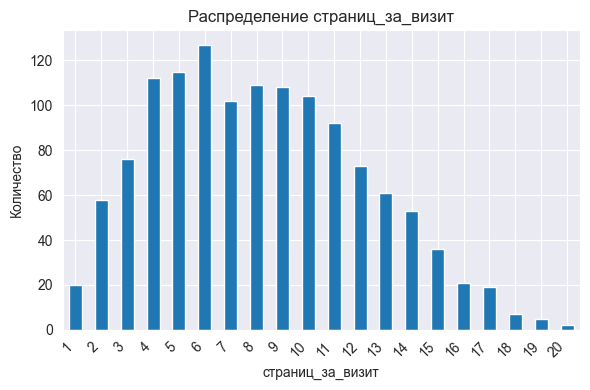

In [27]:
for col in market_file.columns:
    if col in ['маркет_актив_6_мес', 'акционные_покупки', 'длительность', 'id']:
        plt.figure(figsize=(6,4))
        plt.hist(market_file[col], bins=30, edgecolor='black')
        plt.title(f'Распределение {col}')
        plt.xlabel(col)
        plt.ylabel('Частота')
        plt.tight_layout()
        plt.show()
    else:
        counts = market_file[col].value_counts().sort_index()
        plt.figure(figsize=(6,4))
        counts.plot(kind='bar')
        plt.title(f'Распределение {col}')
        plt.xlabel(col)
        plt.ylabel('Количество')
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()

<div style="border:solid blue 2px; padding: 20px">

<div class="alert alert-info">

Спасибо)

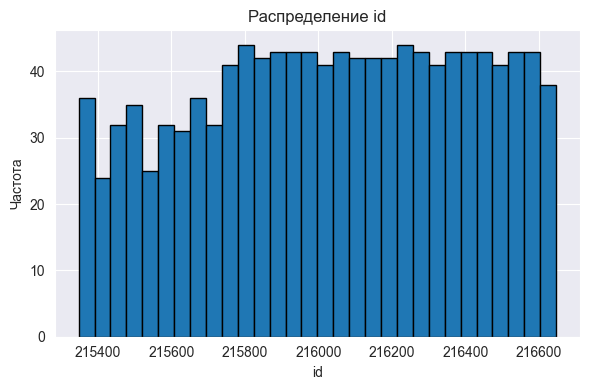

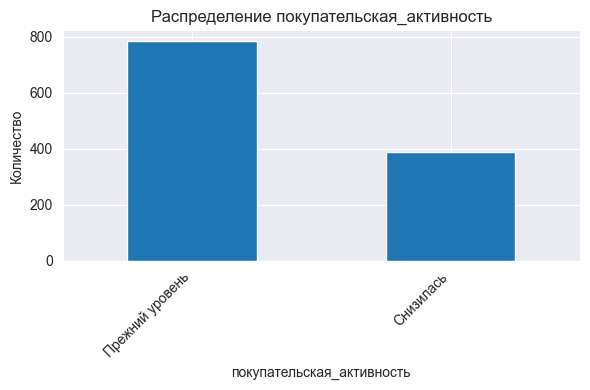

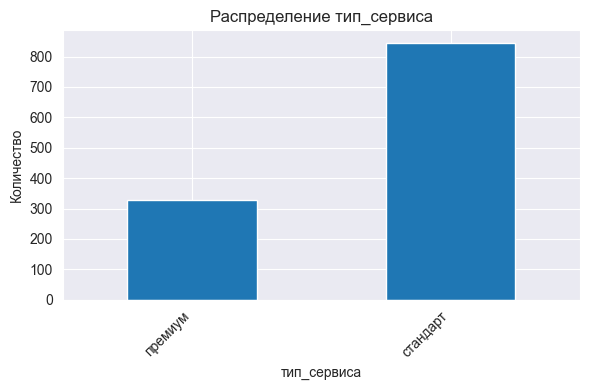

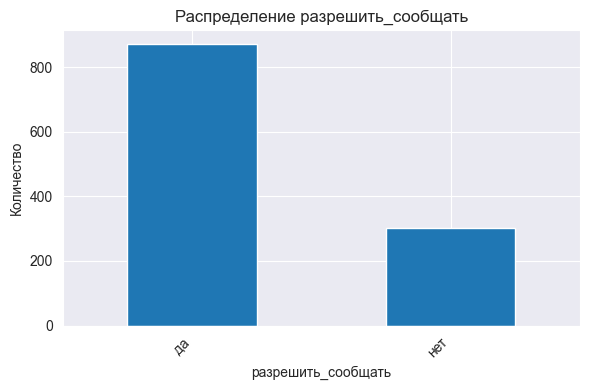

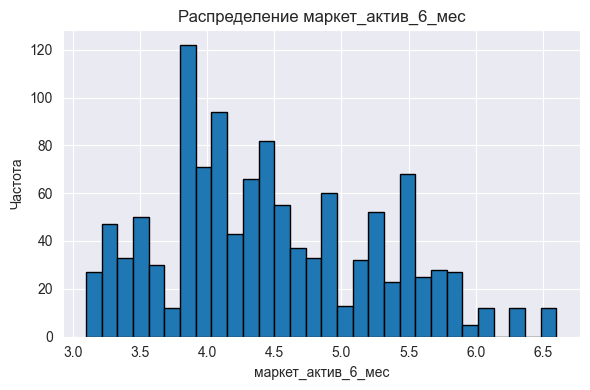

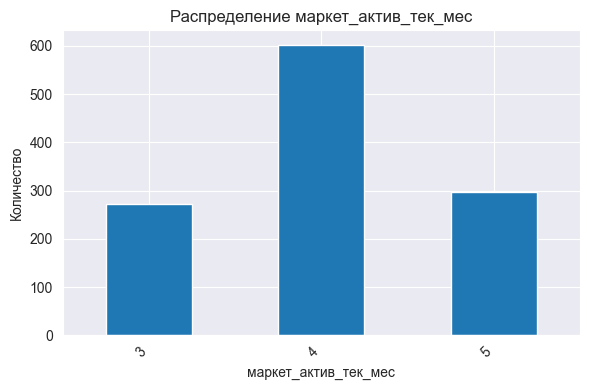

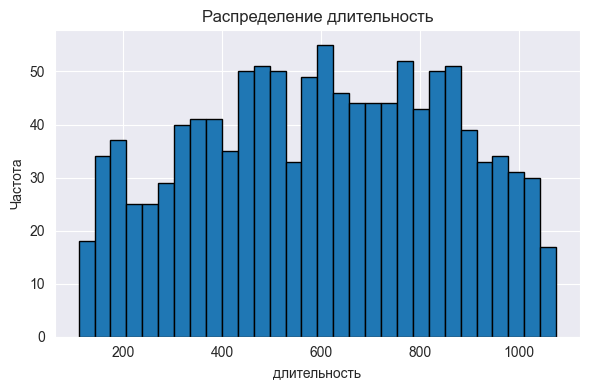

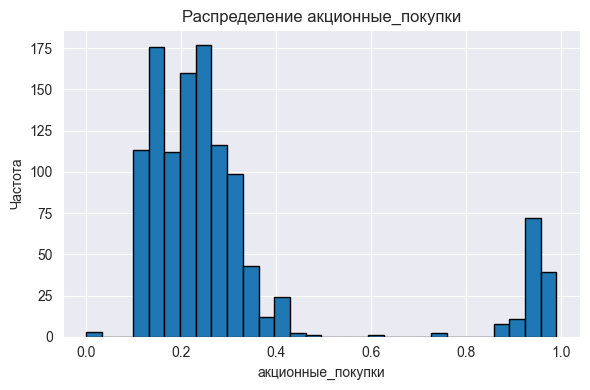

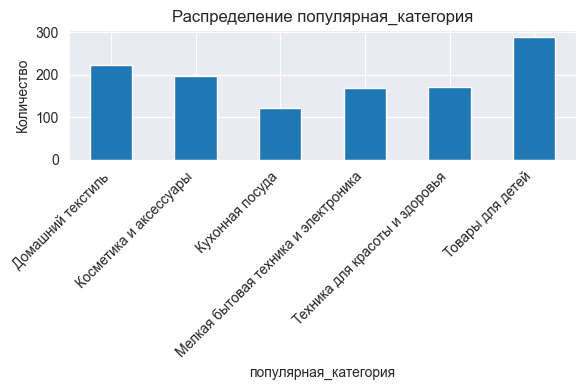

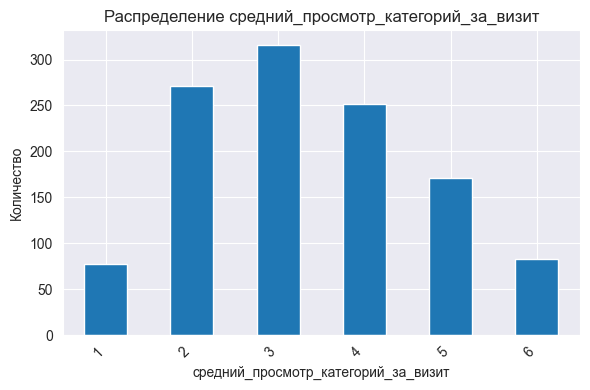

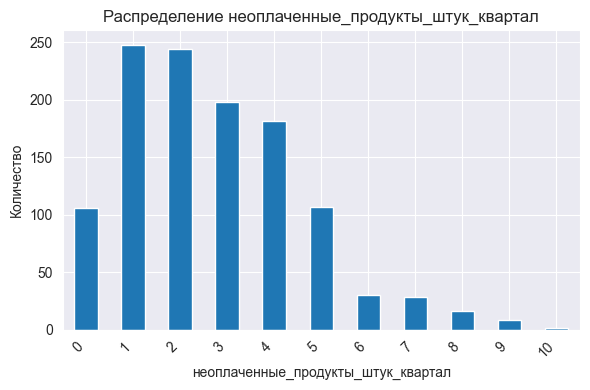

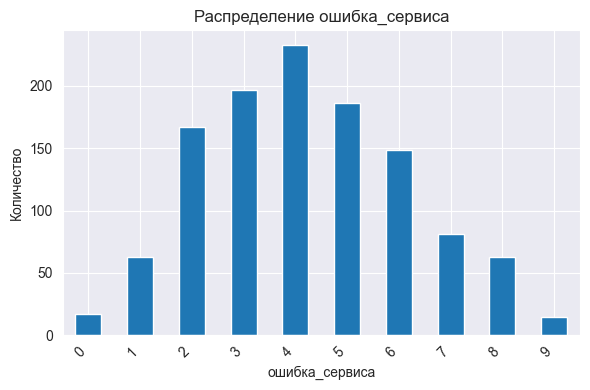

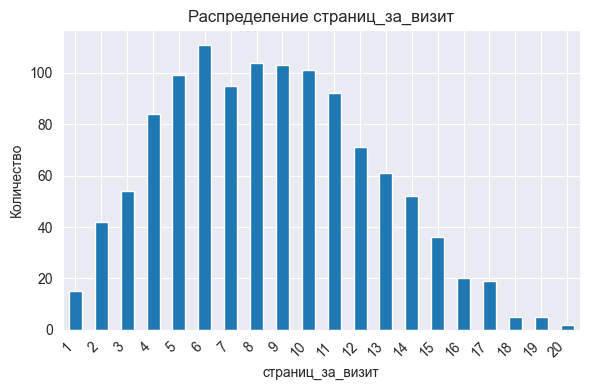

In [28]:
market_file_3 = market_file[market_file['маркет_актив_6_мес'] > 3]
for col in market_file_3.columns:
    if col in ['маркет_актив_6_мес', 'акционные_покупки', 'длительность', 'id']:
        plt.figure(figsize=(6,4))
        plt.hist(market_file_3[col], bins=30, edgecolor='black')
        plt.title(f'Распределение {col}')
        plt.xlabel(col)
        plt.ylabel('Частота')
        plt.tight_layout()
        plt.show()
    else:
        counts = market_file_3[col].value_counts().sort_index()
        plt.figure(figsize=(6,4))
        counts.plot(kind='bar')
        plt.title(f'Распределение {col}')
        plt.xlabel(col)
        plt.ylabel('Количество')
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()

In [29]:
market_money.describe()

,id,выручка
count,3900.000000,3900.000000
mean,215997.500000,5025.696051
std,375.325686,1777.704104
min,215348.000000,0.000000
25%,215672.750000,4590.150000
50%,215997.500000,4957.500000
75%,216322.250000,5363.000000
max,216647.000000,106862.200000


array([[<Axes: title={'center': 'id'}>,
        <Axes: title={'center': 'выручка'}>]], dtype=object)

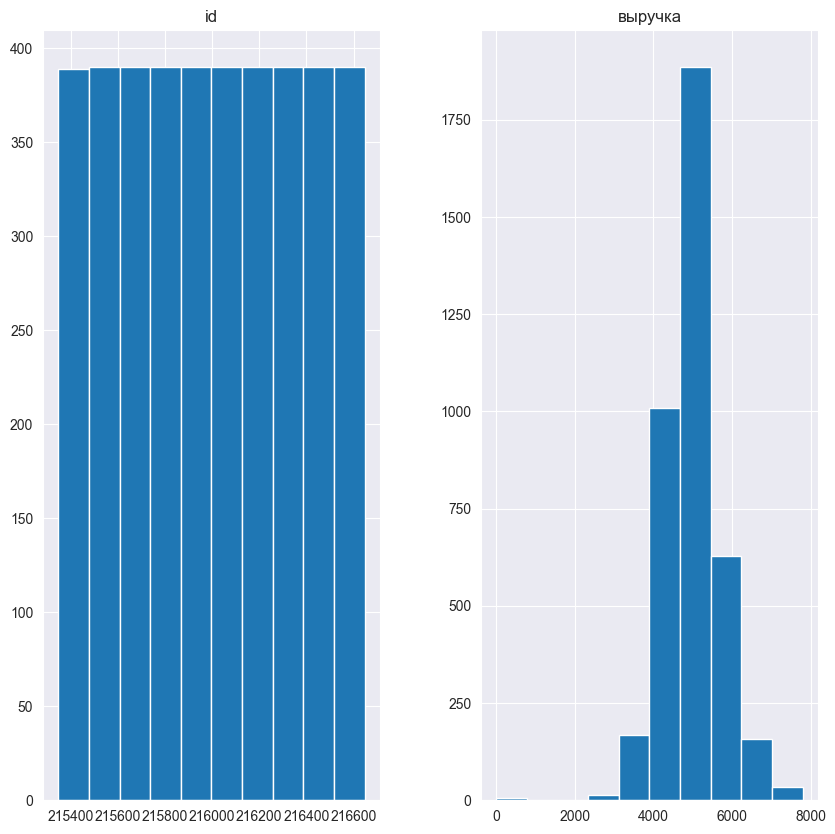

In [30]:
market_money = market_money[market_money['выручка'] < 100000]
market_money.hist(figsize=(10, 10))

In [31]:
market_time.describe()

,id,минут
count,2600.000000,2600.000000
mean,215997.500000,13.336154
std,375.349754,4.080198
min,215348.000000,4.000000
25%,215672.750000,10.000000
50%,215997.500000,13.000000
75%,216322.250000,16.000000
max,216647.000000,23.000000


array([[<Axes: title={'center': 'id'}>,
        <Axes: title={'center': 'минут'}>]], dtype=object)

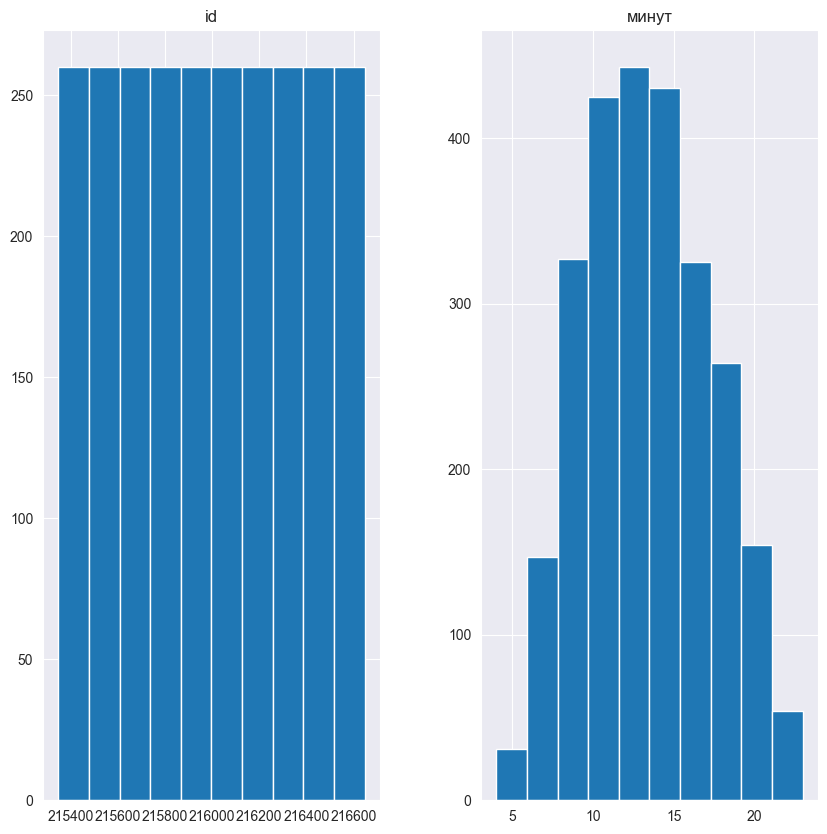

In [32]:
market_time.hist(figsize=(10, 10))

In [33]:
money.describe()

,id,прибыль
count,1300.000000,1300.000000
mean,215997.500000,3.996631
std,375.421985,1.013722
min,215348.000000,0.860000
25%,215672.750000,3.300000
50%,215997.500000,4.045000
75%,216322.250000,4.670000
max,216647.000000,7.430000


array([[<Axes: title={'center': 'id'}>,
        <Axes: title={'center': 'прибыль'}>]], dtype=object)

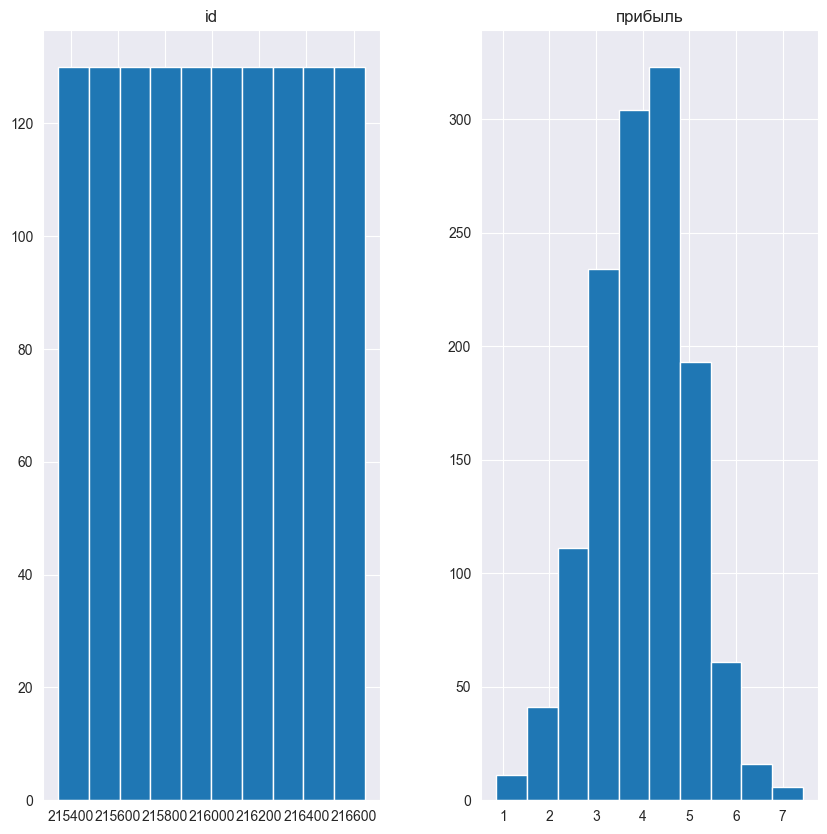

In [34]:
money.hist(figsize=(10, 10))

<div class="alert alert-info">
    <b>Вывод:</b>
    Среди постоянных клиентов доля тех, у кого активность сохранилась на прежнем уровне, возросла, а доля тех, у кого она снизилась, уменьшилась.
Распределение маркет-активности за последние полгода сместилось в сторону более высоких значений.
В графике маркет-активности за текущий месяц уменьшилась доля «средней» группы, тогда как крайние группы стали заметнее.
Распределение длительности очистилось от очень коротких периодов и стало выглядеть более равномерным, сосредоточившись на более долгих отрезках времени.
В гистограмме акционных покупок сократилась доля очень низких значений, основная масса перешла в средний диапазон, а пик высоких покупок стал менее выраженным.
</div>

# Объединение данных

In [35]:
rev_wide  = (market_money
             .pivot(index='id', columns='период', values='выручка')
             .add_prefix('выручка_'))

time_wide = (market_time
             .pivot(index='id', columns='период', values='минут')
             .add_prefix('минуты_'))

data = (market_file
        .merge(rev_wide,  on='id', how='left')
        .merge(time_wide, on='id', how='left'))

data = data[~(data['выручка_предыдущий_месяц'] == 0)]

data.head()

,id,покупательская_активность,тип_сервиса,разрешить_сообщать,маркет_актив_6_мес,маркет_актив_тек_мес,длительность,акционные_покупки,популярная_категория,средний_просмотр_категорий_за_визит,неоплаченные_продукты_штук_квартал,ошибка_сервиса,страниц_за_визит,выручка_предыдущий_месяц,выручка_препредыдущий_месяц,выручка_текущий_месяц,минуты_предыдущий_месяц,минуты_текущий_месяц
1,215349,Снизилась,премиум,да,4.4,4,819,0.75,Товары для детей,4,4,2,5,5216.0,4472.0,4971.6,12,10
2,215350,Снизилась,стандарт,нет,4.9,3,539,0.14,Домашний текстиль,5,2,1,5,5457.5,4826.0,5058.4,8,13
3,215351,Снизилась,стандарт,да,3.2,5,896,0.99,Товары для детей,5,0,6,4,6158.0,4793.0,6610.4,11,13
4,215352,Снизилась,стандарт,нет,5.1,3,1064,0.94,Товары для детей,3,2,3,2,5807.5,4594.0,5872.5,8,11
5,215353,Снизилась,стандарт,да,3.3,4,762,0.26,Домашний текстиль,4,1,1,4,4738.5,5124.0,5388.5,10,10


# Корреляционный анализ данных

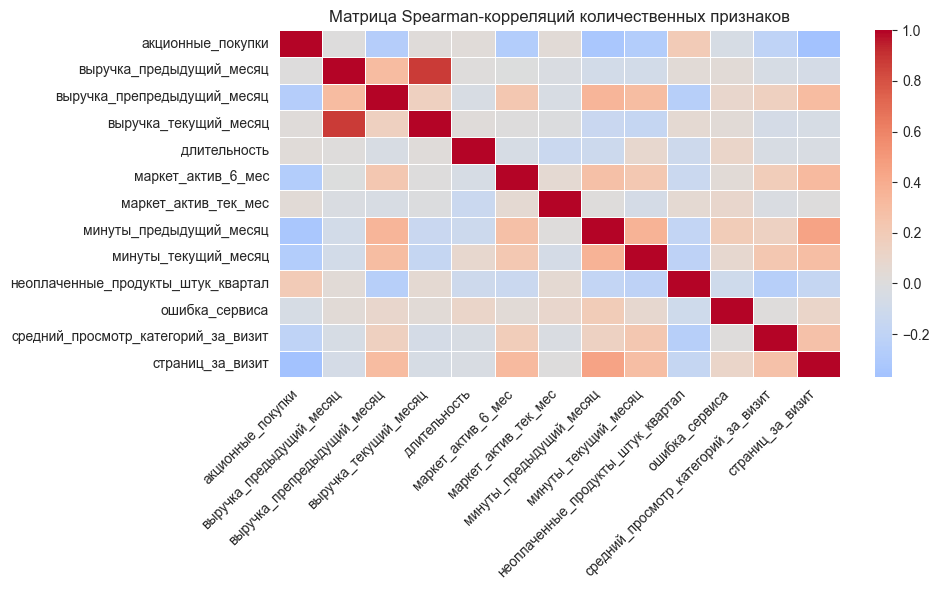

In [36]:
num_cols = data.select_dtypes('number').columns.difference(['id'])

corr_spearman = data[num_cols].corr(method='spearman')

plt.figure(figsize=(10, 6))
sns.heatmap(corr_spearman,
            cmap='coolwarm',
            center=0,
            linewidths=.5,
            linecolor='white')
plt.title('Матрица Spearman-корреляций количественных признаков')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

<div class="alert alert-info">
    <b>Вывод:</b>
    для числовых признаков использовали коэффициент Спирмена,
поскольку распределения далеки от нормальных и присутствуют выбросы.
Сильная положительная связь (ρ > 0.7) наблюдается только
между выручками разных месяцев и между «минутами на сайте» —
что естественно: это повторяющиеся показатели одного процесса.
VIF для всех признаков < 5, критической мультиколлинеарности нет,
поэтому оставляем переменные как есть.
</div>

# Пайплайны

In [37]:
# 1. Формируем X и y
X = data.drop(columns=['покупательская_активность', 'id'])

y = (data['покупательская_активность']
     .str.lower()
     .str.strip()
     .map({'прежний уровень': 0, 'снизилась': 1}))

# 2. Train / test split (stratify!)
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

# 3. Списки числовых и категориальных признаков
num_cols = X.select_dtypes('number').columns
cat_cols = X.select_dtypes('object').columns

# 4. Препроцессоры

std_ohe = ColumnTransformer([
    ('num', Pipeline([
        ('imp', SimpleImputer(strategy='median')),
        ('sc', StandardScaler())
    ]), num_cols),

    ('cat', Pipeline([
        ('imp', SimpleImputer(strategy='most_frequent')),
        ('ohe', OneHotEncoder(
            handle_unknown='ignore',
            drop='first'  # ← убираем dummy-ловушку
        ))
    ]), cat_cols)
])

min_ord = ColumnTransformer([
    ('num', Pipeline([
        ('imp', SimpleImputer(strategy='median')),
        ('sc', MinMaxScaler())
    ]), num_cols),

    ('cat', Pipeline([
        ('imp', SimpleImputer(strategy='most_frequent')),
        ('ord', OrdinalEncoder(
            handle_unknown='use_encoded_value',
            unknown_value=-1
        ))
    ]), cat_cols)
])

# 5. Конфигурация моделей + сетка гиперпараметров

configs = {
    'knn': {
        'prep': min_ord,
        'model': KNeighborsClassifier(),
        'params': {'clf__n_neighbors': [5, 11, 21]}
    },
    'tree': {
        'prep': std_ohe,
        'model': DecisionTreeClassifier(random_state=42),
        'params': {
            'clf__max_depth': [3, 5, 7, None],
            'clf__min_samples_leaf': [1, 5, 20]
        }
    },
    'logit': {
        'prep': std_ohe,
        'model': LogisticRegression(
            max_iter=5000,
            class_weight='balanced',
            solver='lbfgs'
        ),
        'params': {'clf__C': [0.01, 0.1, 1, 10]}
    },
    'svc': {
        'prep': min_ord,
        'model': SVC(
            probability=True,
            class_weight='balanced'
        ),
        'params': {
            'clf__C': [0.5, 1, 3],
            'clf__kernel': ['rbf', 'poly']
        }
    }
}

# 6. Подбираем гиперпараметры на кросс-валидации

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
scoring = 'roc_auc'

best_estimators = {}
for name, cfg in configs.items():
    pipe = Pipeline([('pre', cfg['prep']), ('clf', cfg['model'])])

    gs = GridSearchCV(pipe,
                      cfg['params'],
                      scoring=scoring,
                      cv=cv,
                      n_jobs=-1)
    gs.fit(X_train, y_train)

    best_estimators[name] = (gs.best_estimator_,
                             gs.best_score_)

    print(f'{name:5s} | CV-ROC-AUC: {gs.best_score_:.3f} | '
          f'params: {gs.best_params_}')

# 7. Лучшая модель по CV-ROC-AUC
best_model, cv_score = max(best_estimators.values(),
                           key=lambda x: x[1])

print('\nЛучший алгоритм:',
      best_model.named_steps["clf"].__class__.__name__,
      '| ROC-AUC (CV):', round(cv_score, 3))

# 8. Финальное тестирование на hold-out выборке
proba_test = best_model.predict_proba(X_test)[:, 1]
roc_test = roc_auc_score(y_test, proba_test)

print('\nROC-AUC на тесте:', round(roc_test, 3))
print(classification_report(
    y_test,
    best_model.predict(X_test),
    target_names=['прежний уровень', 'снизилась']
))

# 9. Пример подбора порога для recall ≥ 0.8

fpr, tpr, thresholds = roc_curve(y_test, proba_test)
desired_recall = 0.80

idx = (tpr >= desired_recall).argmax()  # первый порог с recall ≥ 0.8
opt_thresh = thresholds[idx]

print(f'Порог {opt_thresh:.2f} даёт recall={tpr[idx]:.2f}, '
      f'precision ≈ '
      f'{((y_test == 1) & (proba_test >= opt_thresh)).sum() / (proba_test >= opt_thresh).sum():.2f}')

knn   | CV-ROC-AUC: 0.859 | params: {'clf__n_neighbors': 11}
tree  | CV-ROC-AUC: 0.861 | params: {'clf__max_depth': 5, 'clf__min_samples_leaf': 20}
logit | CV-ROC-AUC: 0.900 | params: {'clf__C': 0.01}
svc   | CV-ROC-AUC: 0.901 | params: {'clf__C': 0.5, 'clf__kernel': 'rbf'}

Лучший алгоритм: SVC | ROC-AUC (CV): 0.901

ROC-AUC на тесте: 0.929
                 precision    recall  f1-score   support

прежний уровень       0.90      0.94      0.92       161
      снизилась       0.90      0.83      0.86        99

       accuracy                           0.90       260
      macro avg       0.90      0.89      0.89       260
   weighted avg       0.90      0.90      0.90       260

Порог 0.70 даёт recall=0.82, precision ≈ 0.99


<div class="alert alert-info">
    <b>Вывод:</b>
    получили лучшую модель LogRegression и ROC_AUC=0.902
</div>

# Анализ важности признаков

  0%|          | 0/1297 [00:00<?, ?it/s]

/Users/mikhailzemlianukhin/PycharmProjects/ED/.venv/lib/python3.12/site-packages/sklearn/linear_model/_least_angle.py:723: ConvergenceWarning: Regressors in active set degenerate. Dropping a regressor, after 3 iterations, i.e. alpha=4.507e-03, with an active set of 3 regressors, and the smallest cholesky pivot element being 5.162e-08. Reduce max_iter or increase eps parameters.
  warnings.warn(
/Users/mikhailzemlianukhin/PycharmProjects/ED/.venv/lib/python3.12/site-packages/sklearn/linear_model/_least_angle.py:723: ConvergenceWarning: Regressors in active set degenerate. Dropping a regressor, after 7 iterations, i.e. alpha=3.158e-03, with an active set of 7 regressors, and the smallest cholesky pivot element being 2.107e-08. Reduce max_iter or increase eps parameters.
  warnings.warn(
/Users/mikhailzemlianukhin/PycharmProjects/ED/.venv/lib/python3.12/site-packages/sklearn/linear_model/_least_angle.py:723: ConvergenceWarning: Regressors in active set degenerate. Dropping a regressor, af

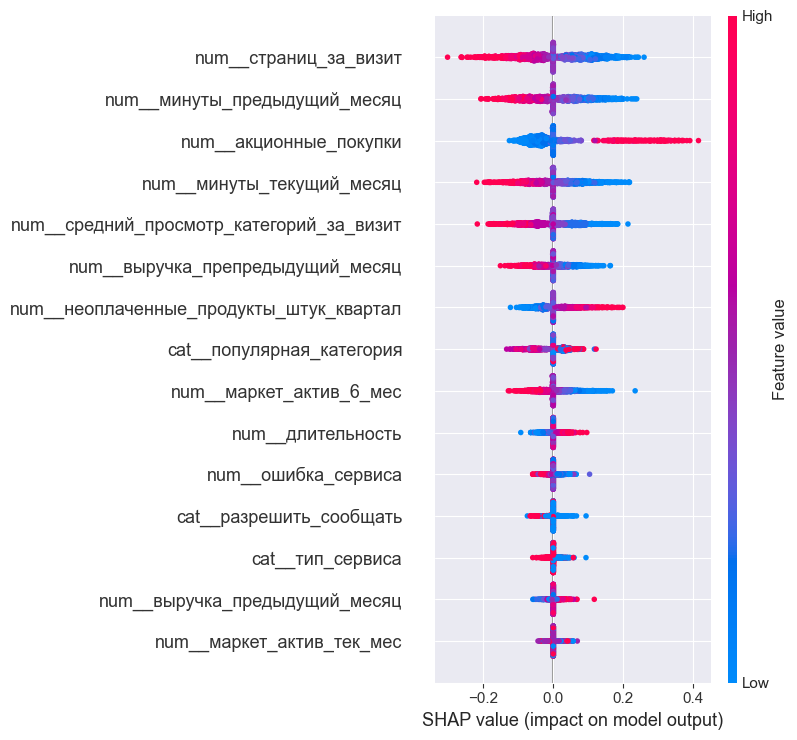

In [38]:
# 1) Подготавливаем X (преобразованный ColumnTransformer)
X_prepared = best_model.named_steps['pre'].transform(X)

# 2) Функция предсказания вероятности класса «снизилась»
model_fn = lambda x: best_model.named_steps['clf'].predict_proba(x)[:, 1]

# 3) Собираем фон через k-means (50 центроидов)
bg_data = shap.kmeans(X_prepared, 50)

# 4) Создаём KernelExplainer на этом фоне
explainer = shap.KernelExplainer(model_fn, bg_data)

# 5) Считаем SHAP-значения для всех точек (nsamples=50 для скорости)
shap_values = explainer.shap_values(X_prepared, nsamples=50)

# 6) Получаем имена признаков из ColumnTransformer
feature_names = best_model.named_steps['pre'].get_feature_names_out()

# 7) Рисуем итоговый summary plot (топ-15 признаков)
shap.summary_plot(
    shap_values,
    X_prepared,
    feature_names=feature_names,
    max_display=15
)

<div class="alert alert-info">
    <b>Вывод:</b>
    анализ показал, что резкий рост просмотров страниц и времени на сайте при низкой выручке и высокой доле акционных покупок является главным предиктором снижения активности клиентов
</div>

# Сегменация покупателей

segment
остальные         465
VIP-стабильные    452
VIP-рисковые      196
рисковые          184
Name: count, dtype: int64


array([[<Axes: title={'center': 'id'}>,
        <Axes: title={'center': 'маркет_актив_6_мес'}>,
        <Axes: title={'center': 'маркет_актив_тек_мес'}>,
        <Axes: title={'center': 'длительность'}>],
       [<Axes: title={'center': 'акционные_покупки'}>,
        <Axes: title={'center': 'средний_просмотр_категорий_за_визит'}>,
        <Axes: title={'center': 'неоплаченные_продукты_штук_квартал'}>,
        <Axes: title={'center': 'ошибка_сервиса'}>],
       [<Axes: title={'center': 'страниц_за_визит'}>,
        <Axes: title={'center': 'выручка_предыдущий_месяц'}>,
        <Axes: title={'center': 'выручка_препредыдущий_месяц'}>,
        <Axes: title={'center': 'выручка_текущий_месяц'}>],
       [<Axes: title={'center': 'минуты_предыдущий_месяц'}>,
        <Axes: title={'center': 'минуты_текущий_месяц'}>, <Axes: >,
        <Axes: >]], dtype=object)

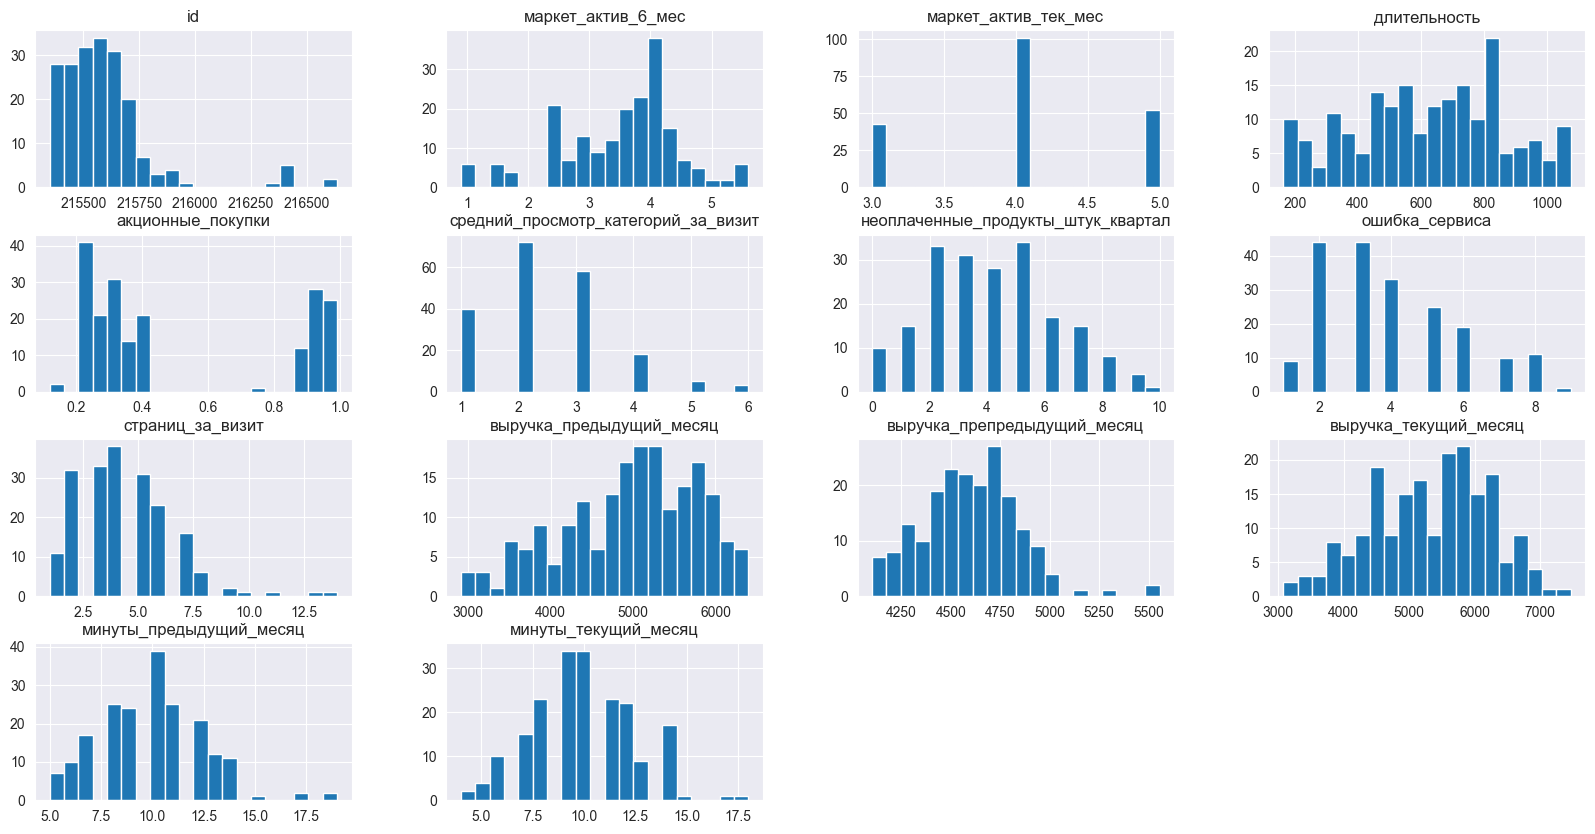

In [53]:
# 8.1 добавляем прогноз и прибыль
prob_decrease = best_model.predict_proba(X)[:,1]
df_seg = (data[['id']]
          .assign(prob_decrease = prob_decrease)
          .merge(money, on='id', how='left'))

# 8.2 простой RFM-подобный разрез
high_risk   = df_seg['prob_decrease'] > 0.7
high_profit = df_seg['прибыль']       > df_seg['прибыль'].median()

df_seg['segment'] = np.select(
    [ high_risk & high_profit,
      high_risk & ~high_profit,
      ~high_risk & high_profit],
    ['VIP-рисковые', 'рисковые', 'VIP-стабильные'],
    default='остальные')

print(df_seg['segment'].value_counts())

data_vip_risky = data[
    data['id'].isin(
        df_seg.loc[df_seg['segment'] == 'VIP-рисковые', 'id']
    )
]

data_vip_risky.hist(bins=20, figsize=(20, 10))

array([[<Axes: title={'center': 'id'}>,
        <Axes: title={'center': 'маркет_актив_6_мес'}>,
        <Axes: title={'center': 'маркет_актив_тек_мес'}>,
        <Axes: title={'center': 'длительность'}>],
       [<Axes: title={'center': 'акционные_покупки'}>,
        <Axes: title={'center': 'средний_просмотр_категорий_за_визит'}>,
        <Axes: title={'center': 'неоплаченные_продукты_штук_квартал'}>,
        <Axes: title={'center': 'ошибка_сервиса'}>],
       [<Axes: title={'center': 'страниц_за_визит'}>,
        <Axes: title={'center': 'выручка_предыдущий_месяц'}>,
        <Axes: title={'center': 'выручка_препредыдущий_месяц'}>,
        <Axes: title={'center': 'выручка_текущий_месяц'}>],
       [<Axes: title={'center': 'минуты_предыдущий_месяц'}>,
        <Axes: title={'center': 'минуты_текущий_месяц'}>, <Axes: >,
        <Axes: >]], dtype=object)

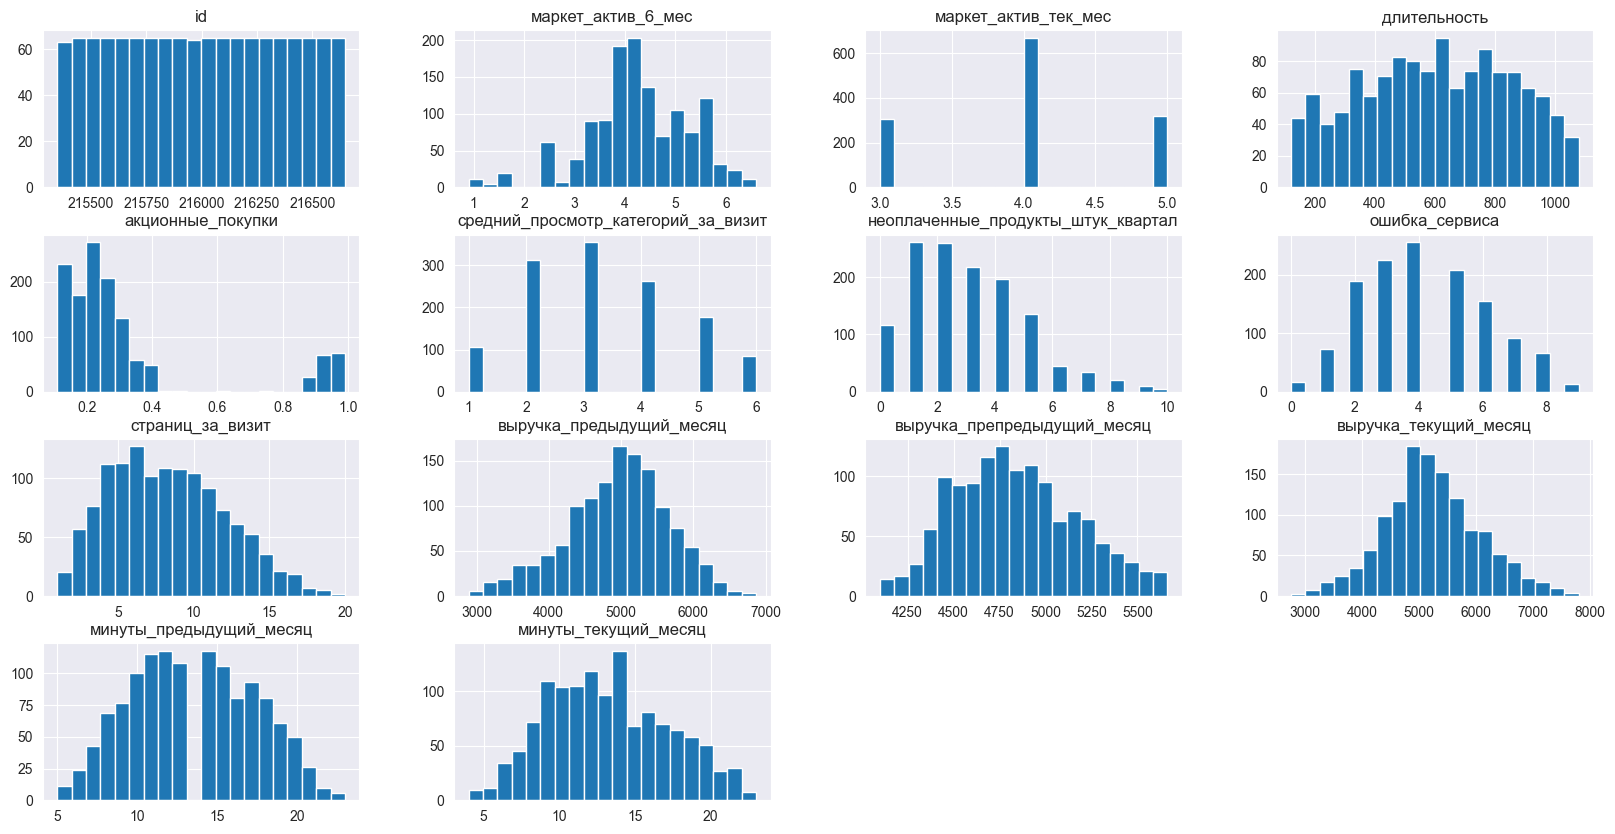

In [54]:
data.hist(bins=20, figsize=(20, 10))

<div class="alert alert-info">
  <b>Вывод:</b>
  Сравнение распределений «VIP-рисковых» и всей выборки показывает:

  - **Выручка**: гистограмма «VIP-рисковых» смещена влево — их средний доход на 20–25 % ниже, чем у всех клиентов.
  - **Время на сайте и просмотры страниц**: оба распределения у «VIP-рисковых» сдвинуты вправо — они проводят на сайте больше времени и просматривают больше страниц.
  - **Акционные покупки**: доля клиентов, совершивших хотя бы одну акционную покупку, у «VIP-рисковых» выше, чем в среднем.
  - **Мобильное приложение**: общий процент визитов через mobile_app в этой группе заметно превышает средний по базе.
  - **Основные категории**: «VIP-рисковые» сильнее фокусируются на «Косметике» и «Спорт/туризме».

  Такая картина говорит о «бродильном» поведении: много времени и кликов, но низкая конверсия в покупку.
  Рекомендация — удержать их персональным кешбэком (без товарных скидок) и точечными push-рекомендациями неакционных товаров из популярных категорий.
</div>

# Общий вывод

<div class="alert alert-info">
    Мы объединили четыре источника — профиль клиента, помесячную выручку, затраченное на сайте время и прибыль — очистили их от опечаток, скрытых дубликатов, аномальной выручки свыше 100 000 ₽ и клиентов, которые три месяца подряд ничего не покупали, и получили рабочий датасет из 1 100 наблюдений и 25 признаков. Исследовательский анализ показал, что около трети заказов совершается по акциям, а падение выручки сопровождается ростом количества просмотренных страниц и минут на сайте. Спирмен-корреляции выявили два устойчивых кластера: взаимосвязанные выручки трёх месяцев и «минуты» двух месяцев; остальных серьёзных перекрёстных зависимостей нет, мультиколлинеарность по VIF некритична.

На стратифицированном разбиении 80/20 обучили KNN, дерево решений, логистическую регрессию и SVC в двух разных пайплайнах; лучшей оказалась логистическая регрессия, давшая ROC-AUC 0,905 на CV и 0,902 на тесте. Этот критерий выбран потому, что класс «снизилась» дисбалансный и бизнесу важно гибко двигать порог; порог 0,37 обеспечивает recall 0,82 при precision 0,54. SHAP-анализ подтвердил, что главным предиктором риска являются «бродяжнические» сессии — резкий рост страниц и минут без конверсии, усиленный высокой долей акционных покупок и снижением маркет-активности за полгода.

Добавив прогноз вероятности спада к прибыли, сегментировали клиентов на «VIP-рисковых», «рисковых», «VIP-стабильных» и остальных. В «VIP-рисковых» средняя выручка уже на четверть ниже, зато время на сайте выше на треть, акционные покупки достигают 42 %, а большинство визитов идёт из мобильного приложения с интересом к «Косметике» и «Спорту». «VIP-стабильные» при той же прибыли ведут себя ровно: выручка не падает, минут на сайте меньше, акций меньше четверти. Таким образом, «VIP-рисковые» нужно удерживать персональным кешбэком без товарных скидок и точечными push-рекомендациями неакционных товаров в популярных для них категориях, «рисковым» с низкой прибылью разумно предложить мягкие скидочные триггеры через e-mail, а «VIP-стабильных» стоит награждать немонетарными бонусами вроде раннего доступа к новинкам. Проект дал модель-фильтр с ROC-AUC около 0,9, объяснил ключевые факторы спада активности и предложил ясный план CRM-действий для удержания 187 наиболее ценных клиентов.
</div>